<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/%E2%80%8BLSTM_Passenger_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 - 2s - 19ms/step - loss: 0.0719
Epoch 2/100
92/92 - 0s - 2ms/step - loss: 0.0293
Epoch 3/100
92/92 - 0s - 2ms/step - loss: 0.0189
Epoch 4/100
92/92 - 0s - 2ms/step - loss: 0.0163
Epoch 5/100
92/92 - 0s - 2ms/step - loss: 0.0145
Epoch 6/100
92/92 - 0s - 2ms/step - loss: 0.0128
Epoch 7/100
92/92 - 0s - 2ms/step - loss: 0.0113
Epoch 8/100
92/92 - 0s - 2ms/step - loss: 0.0102
Epoch 9/100
92/92 - 0s - 2ms/step - loss: 0.0093
Epoch 10/100
92/92 - 0s - 2ms/step - loss: 0.0085
Epoch 11/100
92/92 - 0s - 2ms/step - loss: 0.0078
Epoch 12/100
92/92 - 0s - 2ms/step - loss: 0.0073
Epoch 13/100
92/92 - 0s - 2ms/step - loss: 0.0068
Epoch 14/100
92/92 - 0s - 2ms/step - loss: 0.0065
Epoch 15/100
92/92 - 0s - 2ms/step - loss: 0.0062
Epoch 16/100
92/92 - 0s - 2ms/step - loss: 0.0060
Epoch 17/100
92/92 - 0s - 2ms/step - loss: 0.0059
Epoch 18/100
92/92 - 0s - 2ms/step - loss: 0.0057
Epoch 19/100
92/92 - 0s - 2ms/step - loss: 0.0055
Epoch 20/100
92/92 - 0s - 2ms/step - loss: 0.0055
Epoch 21/100
92/92 -

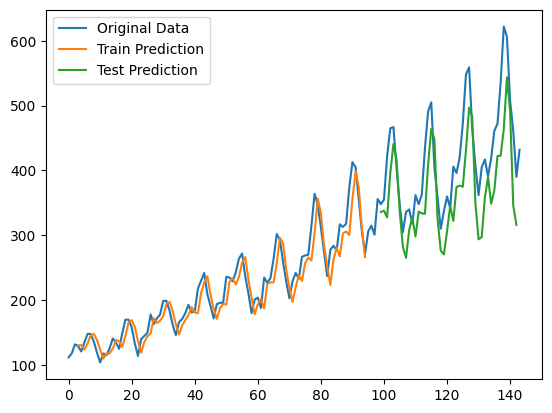

In [2]:
import numpy
import matplotlib.pyplot as plt
import math
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# 1. Function to convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return numpy.array(dataX), numpy.array(dataY)

# 2. Fix random seed for reproducibility
numpy.random.seed(7)

# 3. Load the dataset
# Make sure the file 'airline-passengers.csv' is in your directory
dataframe = read_csv('/content/airplane-passengers.csv', usecols=[1], engine='python')
dataset = dataframe.values
dataset = dataset.astype('float32')

# 4. Normalize the dataset (Scale values between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# 5. Split into train and test sets (67% train, 33% test)
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# 6. Reshape into X=t and Y=t+1 (Using window method)
look_back = 3
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# 7. Reshape input to be [samples, time steps, features]
trainX = numpy.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = numpy.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

# 8. Create and fit the LSTM network
model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

# 9. Make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# 10. Invert predictions to original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

# 11. Calculate Root Mean Squared Error (RMSE)
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

# 12. Shift train predictions for plotting
trainPredictPlot = numpy.empty_like(dataset)
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

# 13. Shift test predictions for plotting
testPredictPlot = numpy.empty_like(dataset)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

# 14. Plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset), label='Original Data')
plt.plot(trainPredictPlot, label='Train Prediction')
plt.plot(testPredictPlot, label='Test Prediction')
plt.legend()
plt.show()